In [87]:
import os
from typing import Optional, Callable, Tuple
from pathlib import Path

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import v2, InterpolationMode
from sklearn.metrics import f1_score, accuracy_score
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
torch.manual_seed(7)
np.random.seed(7)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
class LegoDataset(Dataset):
    """
    A custom PyTorch Dataset for loading Lego images and their associated labels.

    This dataset assumes a CSV file where the first column contains image filenames
    and the subsequent columns contain multi-label classification targets.

    Attributes:
        df (pd.DataFrame): The underlying dataframe containing paths and labels.
        img_dir (str): The base directory where images are stored.
        transform (Optional[Callable]): A function/transform to apply to the images.
        img_paths (np.ndarray): Array of filenames extracted from the CSV.
        labels (np.ndarray): Array of float32 labels extracted from the CSV.
    """

    def __init__(
        self, csv_file: str, img_dir: str = ".", transform: Optional[Callable] = None
    ) -> None:
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform if transform is not None else transforms.ToTensor()

        # paths are in the first column, multilabel targets in the rest
        self.img_paths = self.df.iloc[:, 0].values
        self.labels = self.df.iloc[:, 1:].values.astype("float32")

    def __len__(self) -> int:
        """
        Returns the number of Samples in the dataset.
        """
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Fetches a single image and its corresponding labels.

        Args:
            idx: Index of the sample to fetch.

        Returns:
            A tuple containing (image, label), where image is a tensor
            (after transform) and label is a float32 tensor.
        """

        img_path = os.path.join(self.img_dir, self.img_paths[idx])
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.labels[idx])
        image = self.transform(image)

        return image, label

In [5]:
train_transforms = v2.Compose(
    [
        v2.ToImage(),  # convert input to torchvision image format
        v2.ToDtype(
            torch.float32, scale=True
        ),  # convert to float32 and scale pixel values to [0, 1]
        v2.RandomResizedCrop(
            224, scale=(0.8, 1.0), interpolation=InterpolationMode.NEAREST
        ),
        v2.RandomRotation(degrees=15, interpolation=InterpolationMode.NEAREST, fill=1),
        v2.RandomPerspective(
            distortion_scale=0.3, p=0.2, interpolation=InterpolationMode.NEAREST, fill=1
        ),  # perspective transformation
        v2.RandomHorizontalFlip(p=0.5),
        v2.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),  # normalize using ImageNet stats
    ]
)

In [6]:
eval_transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize(256),
        v2.CenterCrop(224),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [7]:
image_dir = Path("images/")

In [8]:
image_paths = list(image_dir.glob("*"))

In [9]:
image_paths[:5]

[PosixPath('images/HOL273.jpg'),
 PosixPath('images/SW0923.jpg'),
 PosixPath('images/ELF030.jpg'),
 PosixPath('images/AGT021.jpg'),
 PosixPath('images/MK107.jpg')]

In [10]:
image_path = np.random.choice(image_paths)  # type: ignore
image_path

PosixPath('images/CTY0366.jpg')

In [11]:
image = Image.open(image_path).convert("RGB")

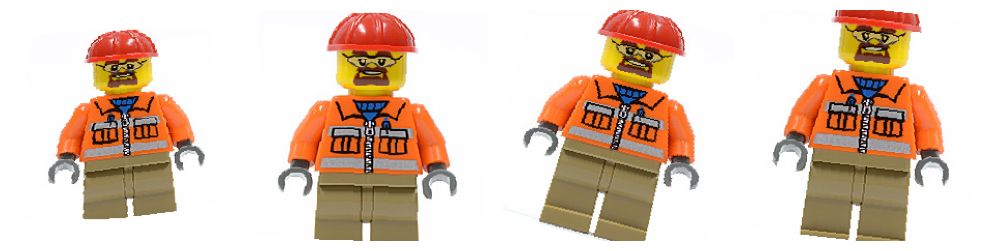

In [12]:
n_rows, n_cols = 1, 4
n_images = n_rows * n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))

for i in range(n_images):
    aug_img = train_transforms(image)

    # convert tensor (C, H, W) to (H, W, C) for plotting
    aug_img = aug_img.permute(1, 2, 0)

    # undoing normalization for visualization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    aug_img = aug_img * std + mean
    aug_img = aug_img.clamp(0, 1)

    ax = axes[i]
    ax.imshow(aug_img)
    ax.axis("off")

fig.tight_layout()
plt.show()

In [13]:
train_dataset = LegoDataset("data/train_data.csv", transform=train_transforms)
valid_dataset = LegoDataset("data/valid_data.csv", transform=eval_transforms)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=4)

In [15]:
print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}")

Train batches: 397 | Valid batches: 50


In [16]:
num_themes = train_dataset.labels.shape[1]
num_themes

55

In [66]:
df = pd.read_csv("data/train_data.csv")
class_names = [col for col in df.columns[1:]]

In [67]:
class_names

['Advanced models',
 'Adventurers',
 'Basic',
 'Belville',
 'BrickLink',
 'Cars',
 'Castle',
 'City',
 'Collectable Minifigures',
 'Creator',
 'Creator Expert',
 'DC Comics Super Heroes',
 'Dacta',
 'Dimensions',
 'Disney',
 'Dreamzzz',
 'Duplo',
 'Education',
 'Elves',
 'Explore',
 'Fabuland',
 'Friends',
 'Games',
 'Gear',
 'Harry Potter',
 'Hidden Side',
 'Icons',
 'Ideas',
 'Indiana Jones',
 'Juniors',
 'Jurassic World',
 'Legends of Chima',
 'Marvel Super Heroes',
 'Minecraft',
 'Miscellaneous',
 'Monkie Kid',
 'Nexo Knights',
 'Ninjago',
 'Pirates',
 'Promotional',
 'Racers',
 'Seasonal',
 'Space',
 'Speed Champions',
 'Sports',
 'Star Wars',
 'Super Mario',
 'Teenage Mutant Ninja Turtles',
 'The Hobbit',
 'The LEGO Batman Movie',
 'The LEGO Movie',
 'The LEGO Movie 2',
 'The LEGO Ninjago Movie',
 'Town',
 'Trains']

In [17]:
weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)

In [18]:
for param in model.parameters():
    param.requires_grad = False

In [19]:
model.fc = nn.Linear(model.fc.in_features, num_themes)
model = model.to(device)

In [20]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

print(f"ResNet50 initialized. Outputting {num_themes} themes.")

ResNet50 initialized. Outputting 55 themes.


In [21]:
epochs = 10

In [22]:
train_losses = []
val_losses = []
val_f1s = []
val_accuracies = []

print("starting train and validation steps ... \n")
for epoch in range(epochs):
    # training the model, here only the last layer's parameters are updated
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # validating the model
    model.eval()
    valid_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item() * images.size(0)

            # Apply Sigmoid to get probabilities, then threshold at 0.5 for binary predictions
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_preds.append(preds.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    valid_loss /= len(valid_loader.dataset)
    val_losses.append(valid_loss)

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    # F1 score
    val_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    val_f1s.append(val_f1)

    # Hamming accuracy
    val_acc = (all_preds == all_targets).mean()
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f} | Valid F1-Macro: {val_f1:.4f} | Valid Acc: {val_acc:.4f}"
    )

print("\nfrozen model training complete!")

starting train and validation steps ... 



Epoch 1/10 | Train Loss: 0.0833 | Valid Loss: 0.0706 | Valid F1-Macro: 0.0291 | Valid Acc: 0.9822
Epoch 2/10 | Train Loss: 0.0603 | Valid Loss: 0.0637 | Valid F1-Macro: 0.0675 | Valid Acc: 0.9828
Epoch 3/10 | Train Loss: 0.0539 | Valid Loss: 0.0603 | Valid F1-Macro: 0.1134 | Valid Acc: 0.9834
Epoch 4/10 | Train Loss: 0.0500 | Valid Loss: 0.0586 | Valid F1-Macro: 0.1389 | Valid Acc: 0.9839
Epoch 5/10 | Train Loss: 0.0472 | Valid Loss: 0.0573 | Valid F1-Macro: 0.1751 | Valid Acc: 0.9841
Epoch 6/10 | Train Loss: 0.0452 | Valid Loss: 0.0567 | Valid F1-Macro: 0.1950 | Valid Acc: 0.9841
Epoch 7/10 | Train Loss: 0.0431 | Valid Loss: 0.0569 | Valid F1-Macro: 0.2041 | Valid Acc: 0.9841
Epoch 8/10 | Train Loss: 0.0422 | Valid Loss: 0.0545 | Valid F1-Macro: 0.2017 | Valid Acc: 0.9843
Epoch 9/10 | Train Loss: 0.0410 | Valid Loss: 0.0549 | Valid F1-Macro: 0.2140 | Valid Acc: 0.9844
Epoch 10/10 | Train Loss: 0.0397 | Valid Loss: 0.0546 | Valid F1-Macro: 0.2370 | Valid Acc: 0.9847

frozen model train

the very high validation accuracy doesn't tell us much, because most of the labels are zeros.

In [23]:
epochs_range = range(1, len(train_losses) + 1)

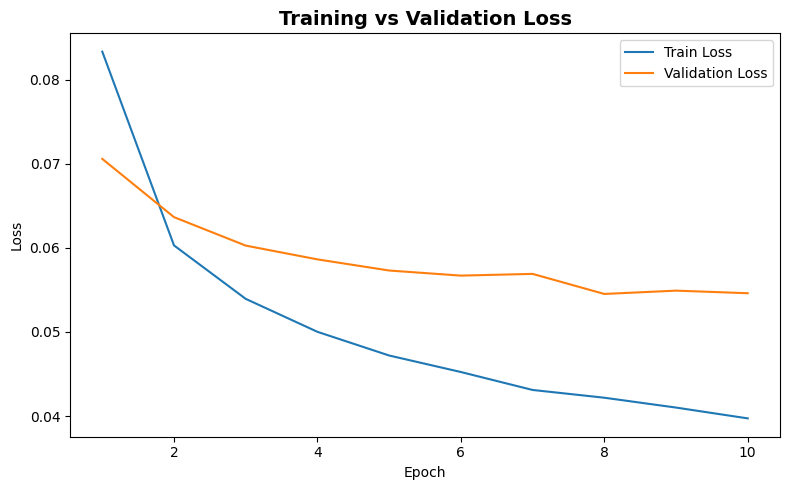

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs_range, train_losses, label="Train Loss")
ax.plot(epochs_range, val_losses, label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss", fontsize=14, fontweight="bold")
ax.legend()

fig.tight_layout()

the model is slightly over-fitting, since the train loss and validation loss don't stay close together, and by the 10th epoch the seem to be diverging

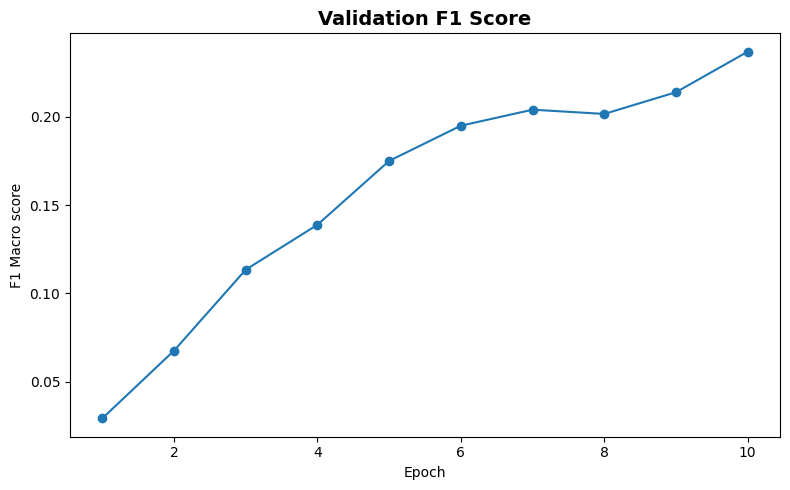

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs_range, val_f1s, marker="o")

ax.set_xlabel("Epoch")
ax.set_ylabel("F1 Macro score")
ax.set_title("Validation F1 Score", fontsize=14, fontweight="bold")

fig.tight_layout()

the F1 score is increasing, but still it is terrible.

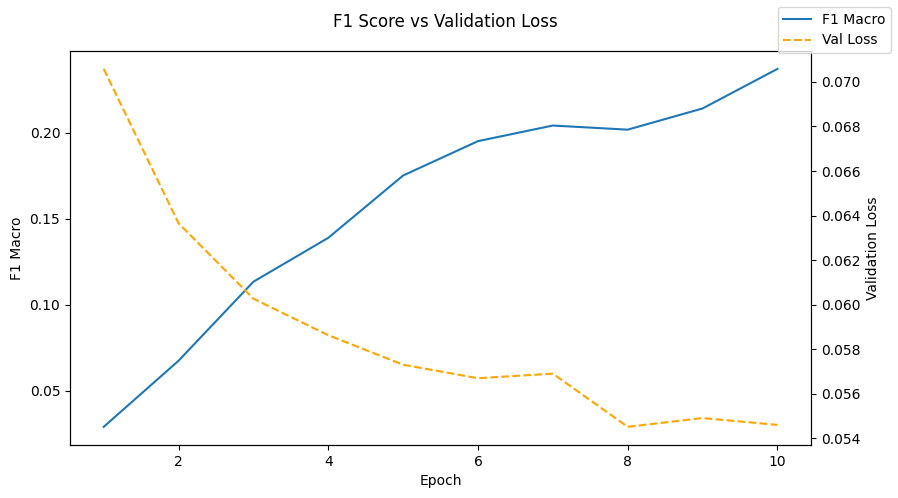

In [26]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(epochs_range, val_f1s, label="F1 Macro")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("F1 Macro")

ax2 = ax1.twinx()
ax2.plot(epochs_range, val_losses, linestyle="--", label="Val Loss", color="orange")
ax2.set_ylabel("Validation Loss")

fig.legend(loc="upper right")
fig.suptitle("F1 Score vs Validation Loss")
fig.tight_layout()

let's unfreeze the model to see if we can make this model better

In [43]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, num_themes)
model = model.to(device)

In [44]:
for p in model.parameters():
    p.requires_grad = False

for p in model.fc.parameters():
    p.requires_grad = True

for p in model.layer4.parameters():
    p.requires_grad = True

In [ ]:
def freeze_batchnorm(model):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False


freeze_batchnorm(model)

In [ ]:
all_labels = []

for _, labels in train_loader:
    all_labels.append(labels)

all_labels = torch.cat(all_labels, dim=0)

pos_weights = (all_labels.shape[0] - all_labels.sum(dim=0)) / (
    all_labels.sum(dim=0) + 1e-6
)
pos_weights = pos_weights.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

In [ ]:
optimizer = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4,
)

In [49]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=4,
)

In [50]:
def find_best_threshold(outputs, targets):
    thresholds = np.linspace(0.1, 0.9, 20)
    best_thresh, best_f1 = 0.5, 0

    for t in thresholds:
        preds = (outputs > t).astype(int)
        f1 = f1_score(targets, preds, average="macro")

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t

    return best_thresh, best_f1

In [52]:
EPOCHS = 20
best_f1 = 0
best_thresh = 0.5

In [53]:
print("Starting the training and validating model ...")
for epoch in range(EPOCHS):
    # train
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # validation
    model.eval()
    valid_outputs = []
    valid_targets = []

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)
            outputs = torch.sigmoid(outputs)

            valid_outputs.append(outputs.cpu())
            valid_targets.append(labels.cpu())

    valid_outputs = torch.cat(valid_outputs).numpy()
    valid_targets = torch.cat(valid_targets).numpy()

    # best threshold
    epoch_thresh, valid_f1 = find_best_threshold(valid_outputs, valid_targets)

    # accuracy at that threshold
    valid_preds = (valid_outputs > epoch_thresh).astype(int)
    valid_acc = accuracy_score(valid_targets, valid_preds)

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Valid F1 (macro): {valid_f1:.4f} | Valid Accuracy: {valid_acc:.4f} | Best Threshold: {epoch_thresh:.2f}"
    )

    # Step scheduler
    scheduler.step(valid_f1)

    # Save best model
    if valid_f1 > best_f1:
        best_f1 = valid_f1
        best_thresh = epoch_thresh
        torch.save(model.state_dict(), "models/ResNet50_unfrozen_tuned.pth")
        print("Saved best model")

print("\n==============================")
print(f"Best F1: {best_f1:.4f}")
print(f"Best Threshold: {best_thresh:.2f}")
print("==============================")

Starting the training and validating model ...

Epoch 1/20 | Train Loss: 389.1308 | Valid F1 (macro): 0.2305 | Valid Accuracy: 0.1061 | Best Threshold: 0.82
Saved best model

Epoch 2/20 | Train Loss: 254.7620 | Valid F1 (macro): 0.2835 | Valid Accuracy: 0.1450 | Best Threshold: 0.86
Saved best model

Epoch 3/20 | Train Loss: 209.5616 | Valid F1 (macro): 0.3268 | Valid Accuracy: 0.1607 | Best Threshold: 0.82
Saved best model

Epoch 4/20 | Train Loss: 180.9357 | Valid F1 (macro): 0.3331 | Valid Accuracy: 0.1670 | Best Threshold: 0.82
Saved best model

Epoch 5/20 | Train Loss: 161.0739 | Valid F1 (macro): 0.3597 | Valid Accuracy: 0.2046 | Best Threshold: 0.86
Saved best model

Epoch 6/20 | Train Loss: 145.5865 | Valid F1 (macro): 0.3783 | Valid Accuracy: 0.2090 | Best Threshold: 0.86
Saved best model

Epoch 7/20 | Train Loss: 130.8205 | Valid F1 (macro): 0.3821 | Valid Accuracy: 0.2524 | Best Threshold: 0.86
Saved best model

Epoch 8/20 | Train Loss: 119.6588 | Valid F1 (macro): 0.3940 | 

## Interpretation of the model

In [54]:
model.eval()

all_outputs = []
all_targets = []
all_images = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = torch.sigmoid(model(images))

        all_outputs.append(outputs.cpu())
        all_targets.append(labels.cpu())
        all_images.append(images.cpu())

valid_outputs = torch.cat(all_outputs).numpy()
valid_targets = torch.cat(all_targets).numpy()
valid_images = torch.cat(all_images)

In [70]:
len(class_names) == valid_targets.shape[1]

True

In [77]:
valid_preds = (valid_outputs > best_thresh).astype(int)
per_class_f1 = f1_score(valid_targets, valid_preds, average=None)

best_idx = int(per_class_f1.argmax())
worst_idx = int(per_class_f1.argmin())

best_class = class_names[best_idx]
worst_class = class_names[worst_idx]

print("Best class:", best_class)
print("Worst class:", worst_class)

Best class: Cars
Worst class: Adventurers


In [88]:
def get_indices_for_class(outputs, targets, class_idx, threshold):
    preds = (outputs > threshold).astype(int)

    tp = np.where((preds[:, class_idx] == 1) & (targets[:, class_idx] == 1))[0]
    fp = np.where((preds[:, class_idx] == 1) & (targets[:, class_idx] == 0))[0]
    fn = np.where((preds[:, class_idx] == 0) & (targets[:, class_idx] == 1))[0]

    return tp, fp, fn

In [93]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output[:, class_idx]

        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        cam = Image.fromarray(np.uint8(cam * 255))
        cam = cam.resize((224, 224), Image.BILINEAR)
        cam = np.array(cam) / 255.0
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam

In [94]:
def overlay_cam(image, cam):
    # Convert CAM to RGB heatmap manually
    cam = np.uint8(255 * cam)
    cam_img = Image.fromarray(cam).convert("L")

    # Apply simple color map (red heat)
    heatmap = Image.merge("RGB", (cam_img, Image.new("L", cam_img.size), Image.new("L", cam_img.size)))
    heatmap = np.array(heatmap) / 255.0

    # Original image
    image = image.permute(1, 2, 0).numpy()
    image = (image - image.min()) / (image.max() + 1e-8)

    overlay = heatmap + image
    overlay = overlay / overlay.max()

    return overlay

In [95]:
def visualize_class(model, class_idx, class_name,
                    val_outputs, val_targets, val_images,
                    threshold, n_samples=3):

    gradcam = GradCAM(model, model.layer4[-1])

    tp, fp, fn = get_indices_for_class(
        val_outputs, val_targets, class_idx, threshold
    )

    print(f"\n===== {class_name} =====")

    categories = {
        "TP (Correct)": tp,
        "FP (Overprediction)": fp,
        "FN (Missed)": fn
    }

    for cat_name, indices in categories.items():
        if len(indices) == 0:
            print(f"{cat_name}: No samples")
            continue

        print(f"{cat_name}: {len(indices)} samples")

        selected = indices[:n_samples]

        plt.figure(figsize=(12, 4))

        for i, idx in enumerate(selected):
            image = val_images[idx]
            input_tensor = image.unsqueeze(0).to(device)

            cam = gradcam.generate(input_tensor, class_idx)
            overlay = overlay_cam(image, cam)

            plt.subplot(1, n_samples, i+1)
            plt.imshow(overlay)
            plt.title(cat_name)
            plt.axis("off")

        plt.show()


===== BEST CLASS ANALYSIS =====

===== Cars =====
TP (Correct): 5 samples


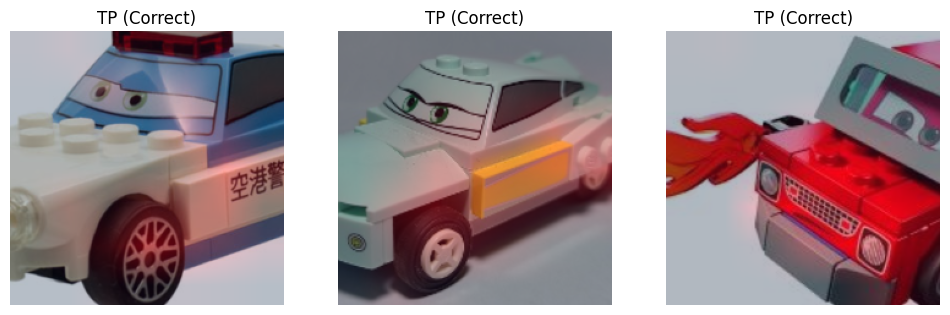

FP (Overprediction): No samples
FN (Missed): No samples

===== WORST CLASS ANALYSIS =====

===== Adventurers =====
TP (Correct): No samples
FP (Overprediction): 2 samples


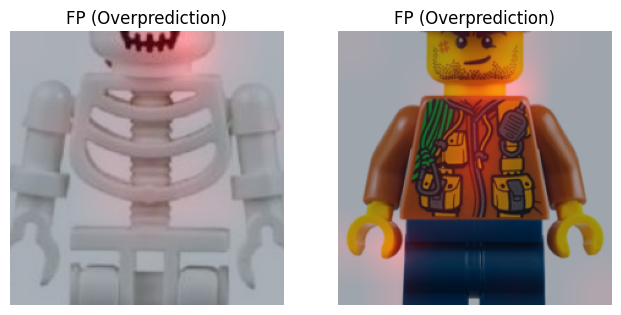

FN (Missed): 5 samples


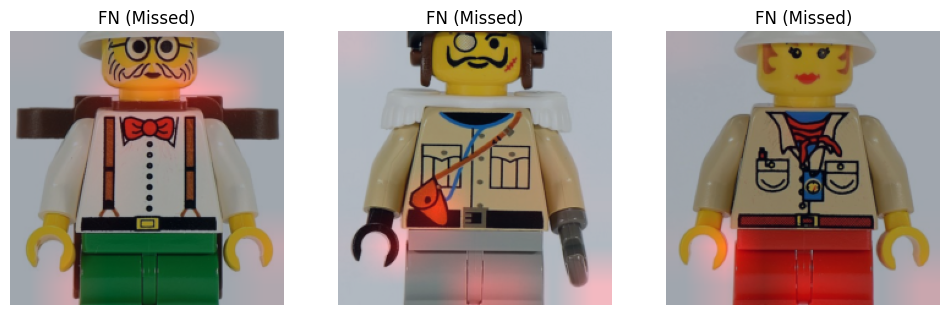

In [96]:
print("\n===== BEST CLASS ANALYSIS =====")
visualize_class(
    model,
    best_idx,
    class_names[best_idx],
    valid_outputs,
    valid_targets,
    valid_images,
    best_thresh
)

print("\n===== WORST CLASS ANALYSIS =====")
visualize_class(
    model,
    worst_idx,
    class_names[worst_idx],
    valid_outputs,
    valid_targets,
    valid_images,
    best_thresh
)